In [3]:
# ----------------------------
# Fast Plant Disease Classification from Google Drive
# ----------------------------

# 1. تركيب Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 2. استيراد المكتبات
# ----------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory
import shutil, os, time
import numpy as np
from tensorflow.keras.preprocessing import image

start_time = time.time()

# ----------------------------
# 3. نسخ البيانات من Google Drive إلى مجلد محلي لتسريع القراءة
# ----------------------------
drive_dir = '/content/drive/MyDrive/Palm Leaves Dataset'  # ضع مسار مجلد البيانات هنا
local_dir = '/content/palmdata'

if os.path.exists(local_dir):
    shutil.rmtree(local_dir)
shutil.copytree(drive_dir, local_dir)

# ----------------------------
# 4. إعداد بيانات التدريب والتحقق
# ----------------------------
img_size = (128, 128)  # لتسريع التدريب
batch_size = 32
validation_split = 0.2
seed = 123

# إنشاء مجموعة التدريب والتحقق
train_ds = image_dataset_from_directory(
    local_dir,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    local_dir,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

# حفظ أسماء الفئات قبل أي عملية map
class_names = train_ds.class_names
print("Class names:", class_names)

# تحسين الأداء
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------
# 5. بناء نموذج MobileNetV2
# ----------------------------
num_classes = len(class_names)  # عدد الفئات

base_model = MobileNetV2(input_shape=(128,128,3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False  # تجميد الطبقات الأساسية

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # عدد العقد يساوي عدد الفئات
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ----------------------------
# 6. تدريب النموذج
# ----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3  # للتجربة، يمكن زيادتها لاحقاً
)

# ----------------------------
# 7. تجربة تصنيف صورة جديدة
# ----------------------------
img_path = '/content/drive/MyDrive/Palm Leaves Dataset/Dubas/Mixed(1).jpg'  # ضع مسار صورتك هنا
img = image.load_img(img_path, target_size=img_size)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
pred = model.predict(x)
class_idx = np.argmax(pred)
print(f"Predicted class: {class_names[class_idx]}")
end_time = time.time()
print(f"Total runtime: {end_time - start_time:.2f} seconds")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3000 files belonging to 4 classes.
Using 2400 files for training.
Found 3000 files belonging to 4 classes.
Using 600 files for validation.
Class names: ['Bug', 'Dubas', 'Healthy', 'Honey']
Epoch 1/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 61s 744ms/step - accuracy: 0.6099 - loss: 0.9921 - val_accuracy: 0.8083 - val_loss: 0.4822
Epoch 2/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 439ms/step - accuracy: 0.8310 - loss: 0.3953 - val_accuracy: 0.8317 - val_loss: 0.4543
Epoch 3/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 439ms/step - accuracy: 0.8930 - loss: 0.2732 - val_accuracy: 0.8200 - val_loss: 0.4526
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: Dubas
Total runtime: 194.83 seconds


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


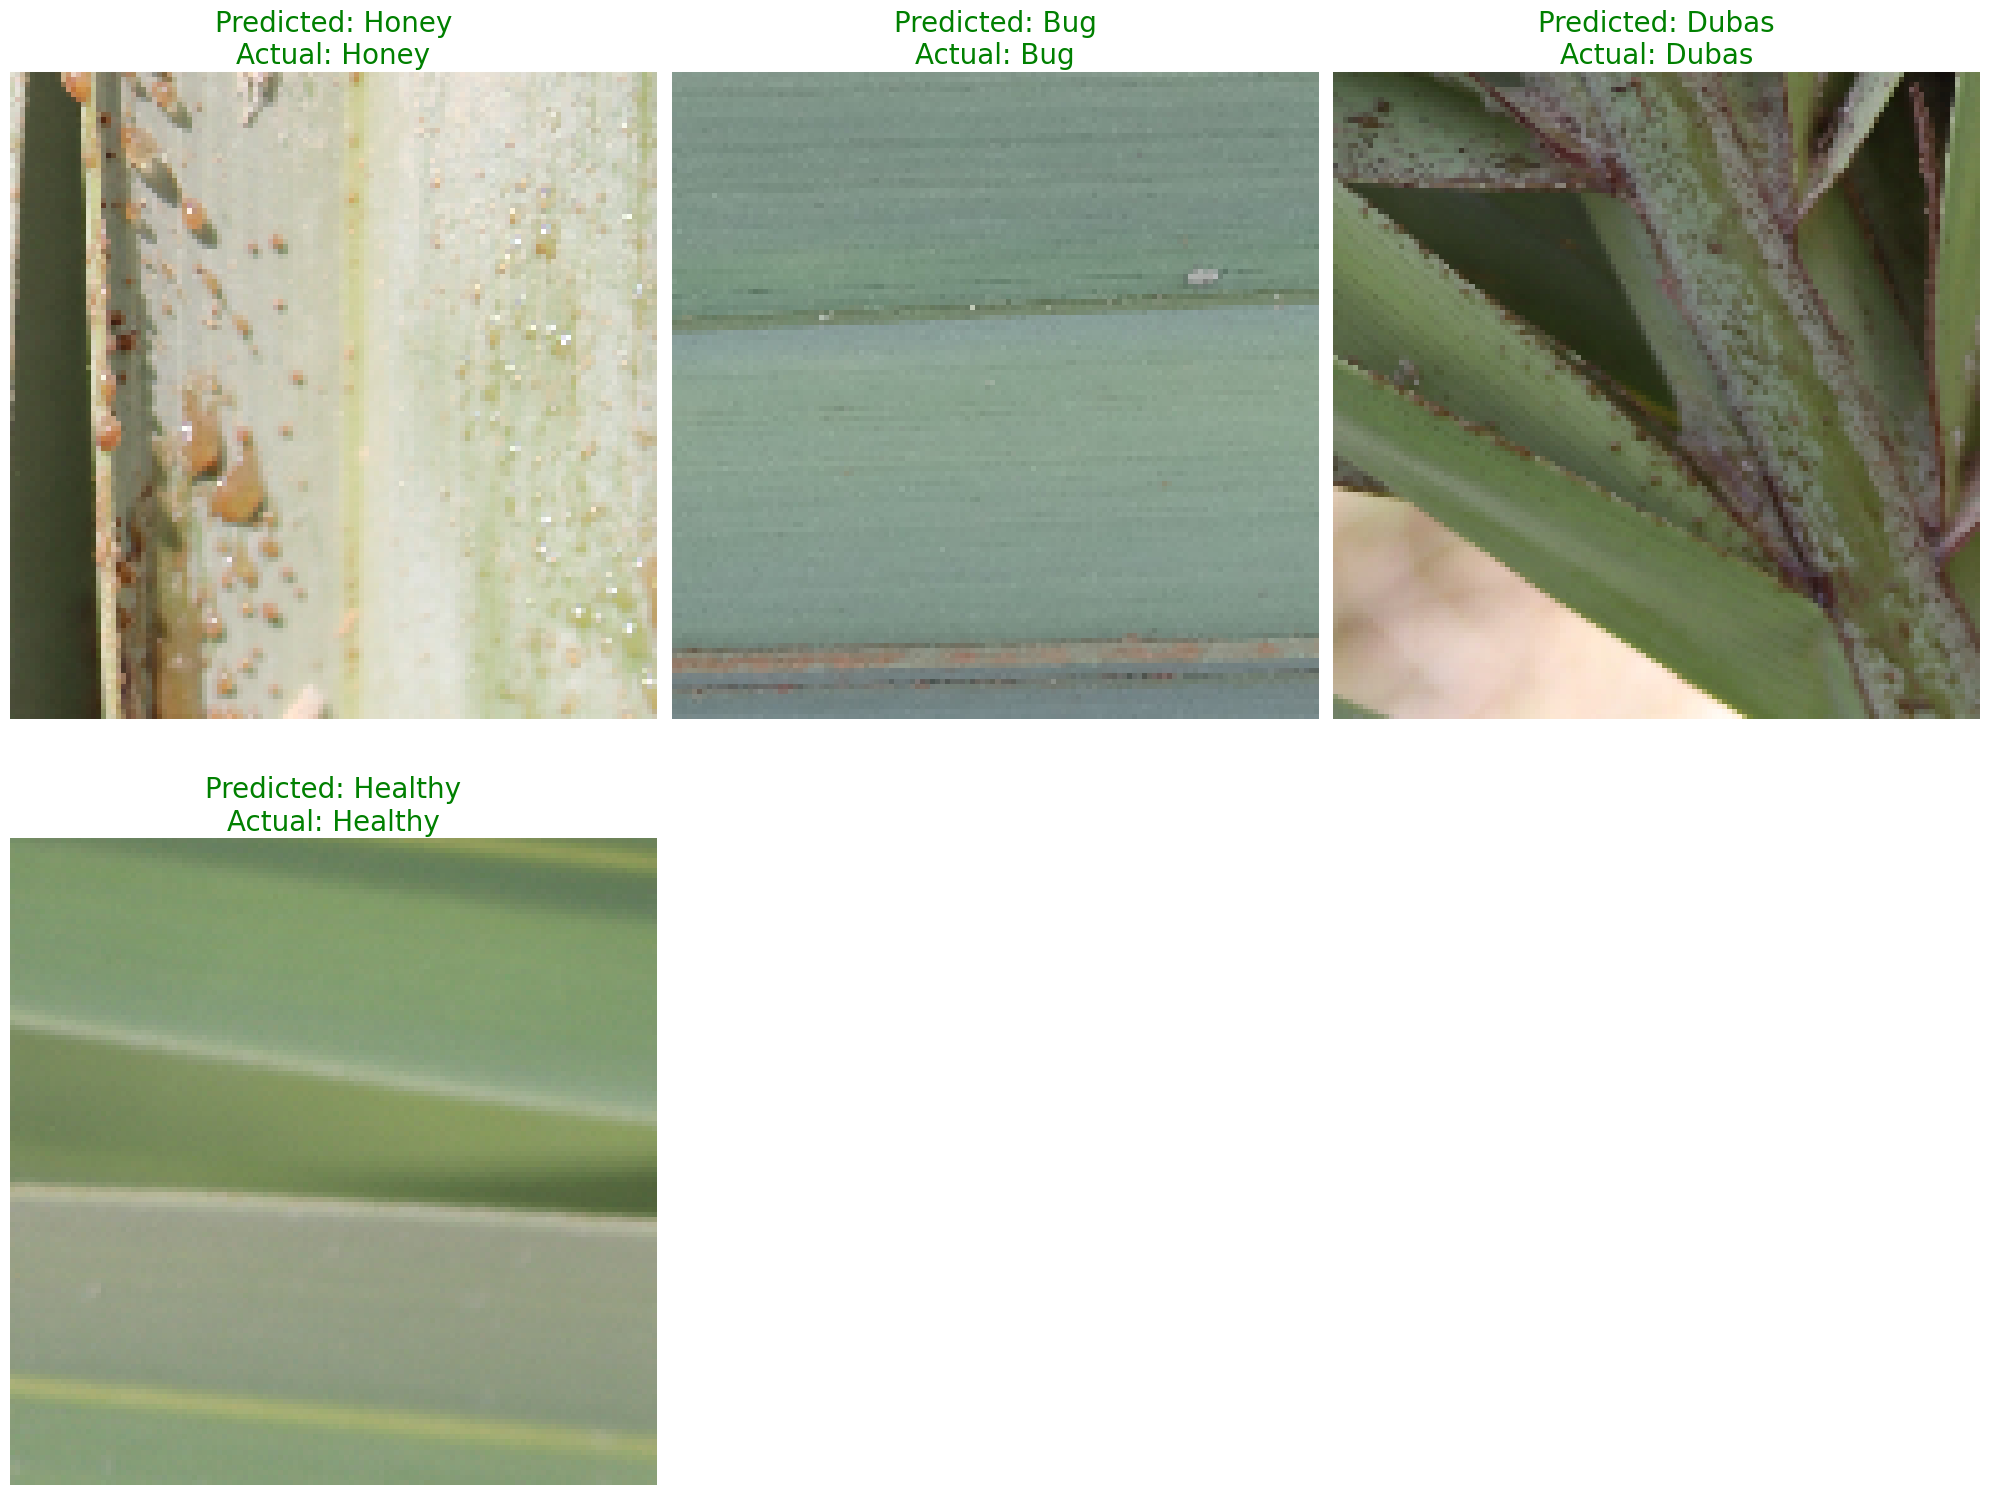

Total images tested: 4
Correct predictions: 4
Accuracy: 100.00%


In [4]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ----------------------------
# إعداد العينة: صورة واحدة من كل فئة
# ----------------------------
images = []
true_labels = []
pred_labels = []

for class_folder in os.listdir(local_dir):
    folder_path = os.path.join(local_dir, class_folder)
    if os.path.isdir(folder_path):
        img_files = os.listdir(folder_path)
        if len(img_files) == 0:
            continue
        img_file = img_files[0]  # أول صورة من كل مجلد
        img_path = os.path.join(folder_path, img_file)
        try:
            img_obj = image.load_img(img_path, target_size=img_size)
            x = image.img_to_array(img_obj)
            x = np.expand_dims(x, axis=0)
            x = preprocess_input(x)

            pred = model.predict(x)
            class_idx = np.argmax(pred)
            predicted_class = class_names[class_idx]

            # تخزين النتائج
            images.append(img_obj)
            true_labels.append(class_folder)
            pred_labels.append(predicted_class)

        except Exception as e:
            print(f"Error processing {img_file}: {e}")

# ----------------------------
# عرض الصور في شبكة مع خطوط كبيرة
# ----------------------------
num_images = len(images)
cols = 3
rows = (num_images + cols - 1) // cols

plt.figure(figsize=(20, 8*rows))
for i in range(num_images):
    plt.subplot(rows, cols, i+1)
    plt.imshow(images[i])
    color = 'green' if true_labels[i] == pred_labels[i] else 'red'
    plt.title(f"Predicted: {pred_labels[i]}\nActual: {true_labels[i]}",
              color=color, fontsize=20)  # خط كبير
    plt.axis('off')

plt.tight_layout()
plt.show()

# ----------------------------
# حساب الدقة
# ----------------------------
correct_predictions = sum([1 for t, p in zip(true_labels, pred_labels) if t==p])
accuracy = correct_predictions / num_images
print(f"Total images tested: {num_images}")
print(f"Correct predictions: {correct_predictions}")
print(f"Accuracy: {accuracy*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


<Figure size 1400x1200 with 0 Axes>

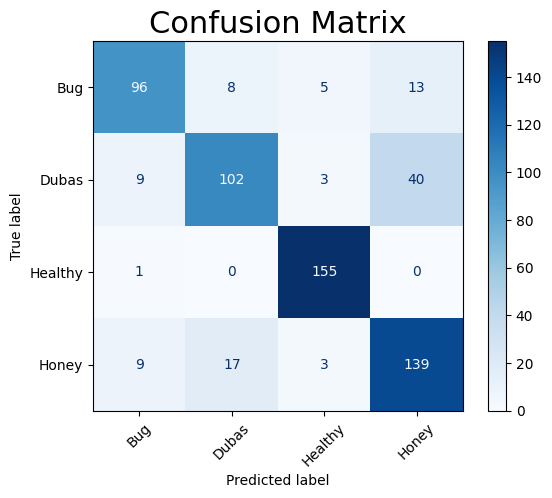

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for batch_images, batch_labels in val_ds:
    preds = model.predict(batch_images)

    # labels مباشرة (ليست one-hot)
    y_true.extend(batch_labels.numpy().astype("int"))

    # توقعات النموذج
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix", fontsize=22)
plt.show()


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

plt.figure(figsize=(18, 18))

base_dir = "/content/drive/MyDrive/newdata"  # عدّل إذا لزم

for i, cls in enumerate(class_names):
    folder = os.path.join(base_dir, cls)
    img_name = os.listdir(folder)[0]  # أول صورة
    img_path = os.path.join(folder, img_name)

    # قراءة الصورة
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    x = np.expand_dims(img_array, axis=0)
    x = preprocess_input(x)

    pred = model.predict(x)
    pred_idx = np.argmax(pred)
    pred_name = class_names[pred_idx]
    confidence = np.max(pred) * 100

    # رسم الصورة
    plt.subplot(4, 4, i+1)
    plt.imshow(img_array.astype('uint8'))
    plt.axis("off")

    # كتابة النص فوق الصورة بخط كبير
    color = "green" if pred_name == cls else "red"
    plt.title(
        f"True: {cls}\nPred: {pred_name}\nAcc: {confidence:.2f}%",
        fontsize=14,
        color=color
    )

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/newdata/Bug'

<Figure size 1800x1800 with 0 Axes>